# Week 9 - Combining Models

Learning contents:
- Base Classifier
    - Train a Least Squares classifier, perform a prediction on the samples, and compute the accuracy
    - Plot the decision boundary for least squares classifier
- Committees
    - Split the training data into M=9 equally sized, non-overlapping parts
    - Train M=9 Least Squares classifiers, one for each data split
    - Perform predictions on the whole dataset using a comitteee of classifiers and compute the accuracy
    - Plot the decision boundary for committee classifier
- Decision tree
    - Fit a DecisionTreeClassifier using scikit-learn, perform a prediction on the data, and compute the accuracy
    - Plot the decision boundary for the DecisionTreeClassifier
- AdaBoost
    - Create an AdaBoost classifier of DecisionTreeClassifiers using the scikit-learn library
    - Plot the decision boundary for the AdaBoostClassifier


In [91]:
# Dependencies
import numpy as np
import scipy
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA 
import matplotlib.pyplot as plt 
import seaborn as sns; sns.set(); sns.set_palette('bright')

In [92]:
# Some plotting functions, we'll be using later


def plot_scatter(data, target, alpha=0.5, legend=True):
    scatter = plt.scatter(data[:, 0], data[:, 1], c=target, edgecolor='none', alpha=alpha, cmap='rainbow')
    if legend:
        plt.legend(*scatter.legend_elements(), loc="upper right", title="Targets")
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    
def plot_mesh(X, pred_fn, n_class=2):
    plt_margin = 5
    x_min, x_max = min(X[:,0]) - plt_margin, max(X[:,0]) + plt_margin
    y_min, y_max = min(X[:,1]) - plt_margin, max(X[:,1]) + plt_margin
    h = 0.1  # step size in the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = pred_fn(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.cm.get_cmap('rainbow', n_class))

# Dataset
We'll be working with a slightly modified version of the digits data

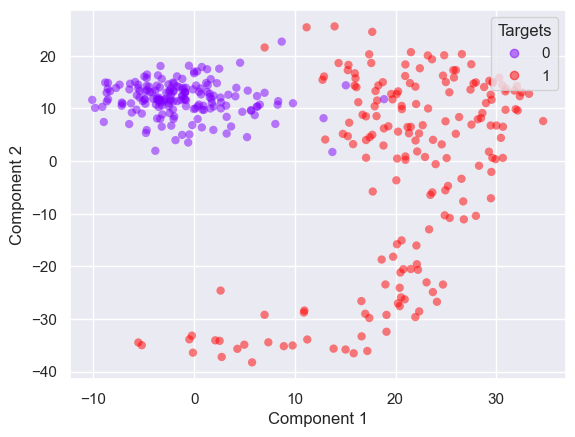

In [93]:
digits = load_digits(n_class=2)

# Get a 2D version of the data using PCA
pca = PCA(n_components=2)
t = digits.target
X = pca.fit_transform(digits.data)

# In order to get a non-linearly seperable case, 
# we'll modify the data a bit this time, 
# translating the '-1' class to the right and up
X = np.where(
    np.repeat(np.expand_dims(t == 1, axis=1), 2, axis=1), 
    X, 
    np.vstack([X[:,0]+20, X[:,1]+10]).T
)

N = len(t) # total number of samples

plot_scatter(X, t)

# 0) Base Classifier

## 0.1) Train a Least Squares classifier, perform a prediction on the samples, and compute the accuracy
Use your solution from the exercise "Week 7 - Linear classification" section 1.1 and 1.2. The accuracy is to be calculated in terms of the proportion of correct predictions compared to the number of predictions and should print a single float.

In [94]:
def optimal_weights(X, T):
    N, M = X.shape
    X_tilde = np.ones((N,M+1))
    
    for n in range(N):
        for m in range(M):
            X_tilde[n,m+1] = X[n,m]
            
    X_tilde_dagger = np.linalg.inv(X_tilde.T @ X_tilde) @ X_tilde.T

    W_tilde = (X_tilde_dagger @ T)[np.newaxis,:]

    return W_tilde, X_tilde

W_tilde, X_tilde = optimal_weights(X, t)

def predict(W, X, a=0.5):
    y = W @ X.T

    result = []
    for y_n in y[0]:
        if y_n >= a:
            result.append(1)
        else:
            result.append(0)
    
    return np.array(result)

preds = predict(W_tilde, X_tilde)
N = len(preds)
print(np.count_nonzero(preds == t) / N)

0.9694444444444444


## 0.2) Plot the decision boundary for least squares classifier
Hint: you can do this by either plotting a line on the boundary or creating a mesh of all predictions (similar to section 1.3 in "week 7 - Linear classification"). You can of course use the helper functions (plot_scatter() and plot_mesh()) given at the start of this file. 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


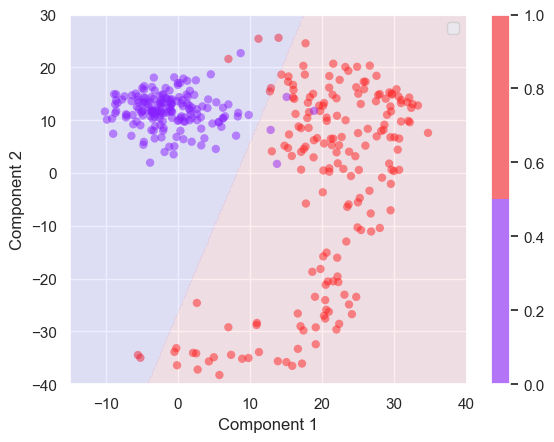

In [95]:
# Handy plotting functions
x_min, x_max = -15, 40
y_min, y_max = -40, 30

def plot_scatter(data, target, n_class=2):
    plt.scatter(data[:, 0], data[:, 1], c=target, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('rainbow', n_class))
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.colorbar()
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)

def plot_decision_boundary(weights):
    w0, w1, w2 = weights[0]
    x_values = np.linspace(x_min, x_max, 200)
    y_values = np.linspace(y_min, y_max, 200)
    xx, yy = np.meshgrid(x_values, y_values)
    zz = w0 + w1 * xx + w2 * yy

    plt.contourf(xx, yy, zz >= 0.5, alpha=0.2, levels=1, colors=['#AAAAFF', '#FFAAAA'])

    # y_line = (0.5 - w0 - w1 * x_values) / w2
    # plt.plot(x_values, y_line, "k--", label="Decision Boundary")
    plt.legend()
    plt.show()

plot_scatter(X, t)
W_least_squares = W_tilde
plot_decision_boundary(W_least_squares)

# 1) Committees

## 1.1) Split the training data into M=9 equally sized, non-overlapping parts
Hint: use the numpy.split() command.

In [96]:
M = 9
X_split = np.split(X, M)
t_split = np.split(t, M)

## 1.2) Train M=9 Least Squares classifiers, one for each (9) data split using the same method as in section 0.1
Hint: loop over the training data containing of the X split and t split zipped together using the zip() command.

In [97]:
W_tilde, X_tilde = [], []

for xi, ti in zip(X_split, t_split):
    Wi, Xi_tilde = optimal_weights(xi, ti)
    W_tilde.append(Wi)
    X_tilde.append(Xi_tilde)

## 1.3) Perform a prediction on the whole dataset using committee of classifiers (lecture 17 slide 4) and compute the accuracy

In [98]:
def committee_prediction(X):
    N, M = X.shape
    X_tilde = np.ones((N, M + 1))
    X_tilde[:, 1:] = X

    member_preds = []
    for Wi in W_tilde:
        preds_i = predict(Wi, X_tilde)   # predict returns 0/1 per sample
        member_preds.append(preds_i)

    y_com = np.mean(member_preds, axis=0)
    y_com = (y_com >= 0.5).astype(int)
    return y_com

y_com = committee_prediction(X)
y_com_accuracy = np.mean(y_com == t)
print("Committee accuracy (majority vote):", y_com_accuracy)

Committee accuracy (majority vote): 0.9583333333333334


## 1.4 Plot the decision boundary for committee classifier

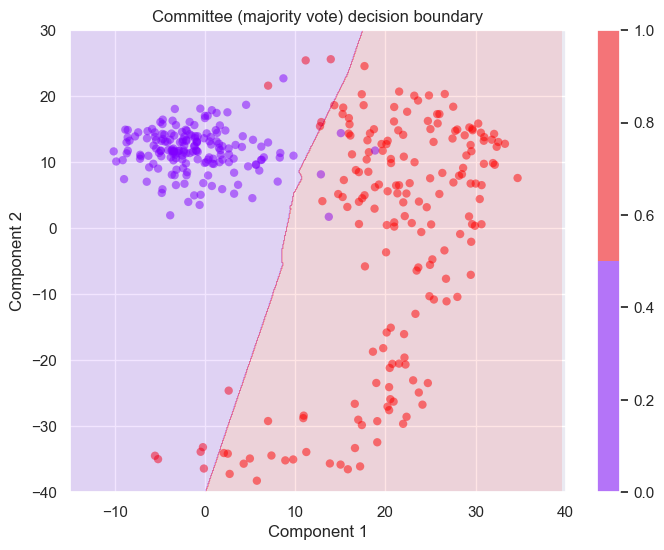

In [99]:
plt.figure(figsize=(8,6))
plot_scatter(X, t)
plot_mesh(X, committee_prediction)
plt.title('Committee (majority vote) decision boundary')
plt.show()

## 2.1) Fit a DecisionTreeClassifier imported from the `scikit-learn` library, perform a prediction on the data, and compute the accuracy
Use `max_depth=3`. You will use fit() and predict() methods of the DecisionTreeClassifier class in order to respectively train and predict from your classifier

In [100]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=0, max_depth=3)
clf.fit(X, t).predict(X)
print("DecisionTreeclassifier accuracy:", clf.score(X, t))

DecisionTreeclassifier accuracy: 0.9861111111111112


## 2.2) Plot the decision boundary for the DecisionTreeClassifier

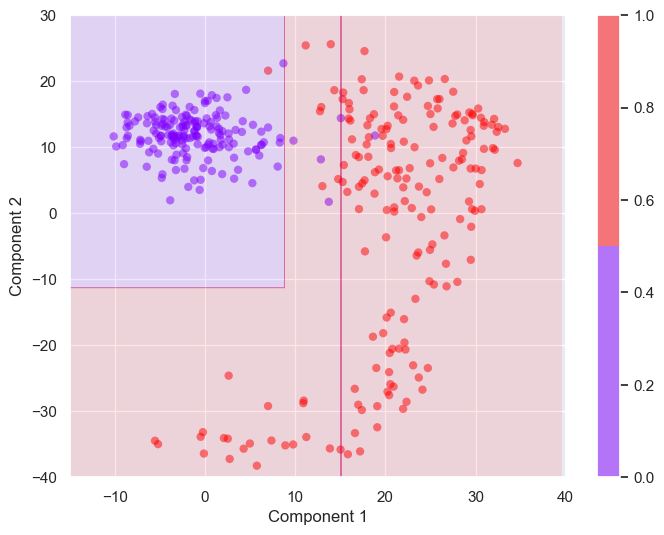

In [101]:
plt.figure(figsize=(8,6))
plot_scatter(X, t)
plot_mesh(X, clf.fit(X, t).predict)
plt.show()

# 3) AdaBoost

## 3.1) Create an AdaBoost classifier of DecisionTreeClassifiers using the `scikit-learn` library, and compute the accuracy
Use a depth of 1 for the `DecisionTreeClassifier` and 7 estimators for the `AdaBoostClassifier`. Use the defaults for the other parameters

In [102]:
from sklearn.ensemble import AdaBoostClassifier
adb_clf = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=7)
adb_clf.fit(X, t).predict(X)
print("AdaBoostClassifier accuracy:", clf.score(X, t))

AdaBoostClassifier accuracy: 0.9861111111111112


## 3.2) Plot the decision boundary for the AdaBoostClassifier

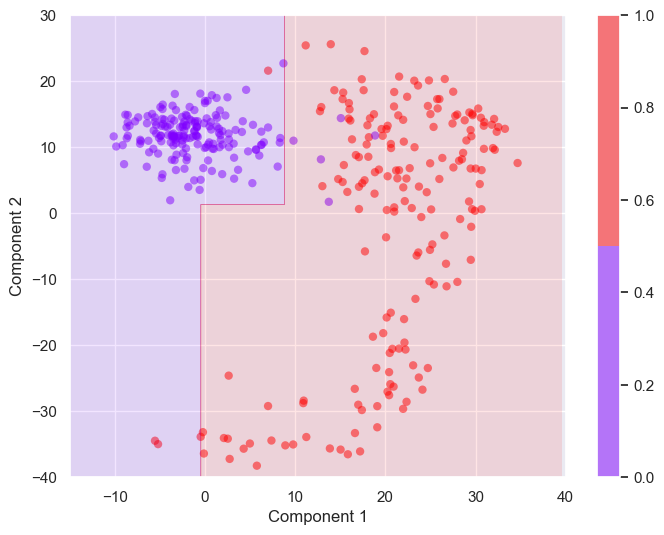

In [103]:
plt.figure(figsize=(8,6))
plot_scatter(X, t)
plot_mesh(X, adb_clf.fit(X, t).predict)
plt.show()